In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.set_printoptions(precision=4, suppress=True)

## Loading datasets

In [51]:
stellar_mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
effective_stellar_temperature = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
stellar_luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

## Dataset Visualization

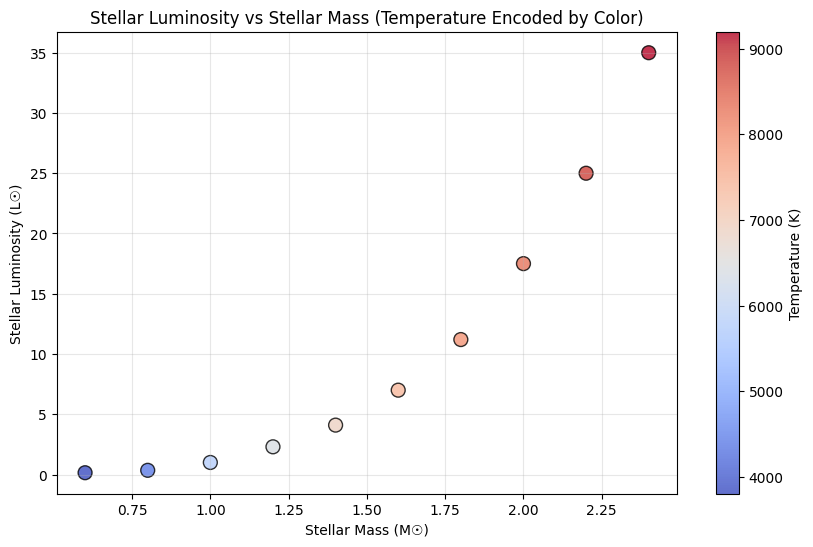

In [52]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    stellar_mass,
    stellar_luminosity,
    c=effective_stellar_temperature,
    cmap="coolwarm",
    s=100,
    edgecolors='black',
    alpha=0.8
)

plt.xlabel("Stellar Mass (M☉)")
plt.ylabel("Stellar Luminosity (L☉)")
plt.title("Stellar Luminosity vs Stellar Mass (Temperature Encoded by Color)")
plt.colorbar(scatter, label="Temperature (K)")
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
def z_score_normalize(X):
    """Z-score normalization: transforms the data to have mean=0 and std=1.

This normalization is ESSENTIAL for gradient descent when
the features have very different scales.

Parameters
----------
X : shape (m, n)
Unnormalized feature matrix.

Returns
-------
X_norm: shape (m, n)
Normalized matrix.
mu: shape (n,)
Means of each feature.
sigma: shape (n,)
Standard deviation of each characteristic.
"""
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm

In [54]:
def predict(X, w, b):
    """Compute predictions f_{w,b}(x) for all examples.

    Parameters
    ----------
    X : shape (m, n)
        Design matrix: each row is x^(i).
    w : shape (n,)
        Parameter vector.
    b : float
        Bias term.

    Returns
    -------
    y_hat : shape (m,)
        Vector of predictions for each example.
    """
    return X @ w + b

## Loss and Gradients

In [55]:
def compute_cost(X, y, w, b):
    """Compute the cost J(w,b) for linear regression with multiple features.

    Uses the vectorized formula:
        J = (1 / (2m)) * (y_hat - y)^T (y_hat - y)

    Parameters
    ----------
    X : shape (m, n)
    y : shape (m,)
    w : shape (n,)
    b : float

    Returns
    -------
    cost : float
    """
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y
    cost = (error @ error) / (2 * m)
    return cost

def compute_gradient(X, y, w, b):
    """Compute the gradients of J with respect to w and b.

    Vectorized formulas:
        dj_dw = (1/m) * X^T (y_hat - y)
        dj_db = (1/m) * sum(y_hat - y)
    """
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y

    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

## Gradient descent + convergence

In [56]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, verbose=True):
    """Run gradient descent to learn w and b.

    Parameters
    ----------
    X : shape (m, n)
    y : shape (m,)
    w_init : shape (n,)
    b_init : float
    alpha : float
        Learning rate.
    num_iterations : int
    verbose : bool
        If True, print progress every 1000 iterations.

    Returns
    -------
    w : np.ndarray, shape (n,)
    b : float
    history_it : list of int
    history_cost : list of float
    """
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % 10 == 0 or i == num_iterations - 1:
            cost = compute_cost(X, y, w, b)
            history_it.append(i)
            history_cost.append(cost)

        if verbose and i % 1000 == 0:
            cost = compute_cost(X, y, w, b)

    return w, b, history_it, history_cost

In [57]:
alpha = 0.1
num_iterations = 10000

# Feature selection experiment

## **M1:** X = [M, T]


M1 Results:
  w = [ 29.4967 -19.406 ]
  b = 10.3600
  Final Cost = 3.552692


/tmp/ipython-input-1949677827.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(stellar_mass, y_predicted, 'b-', color = "orange",linewidth=2, label=f'M1 Prediction')


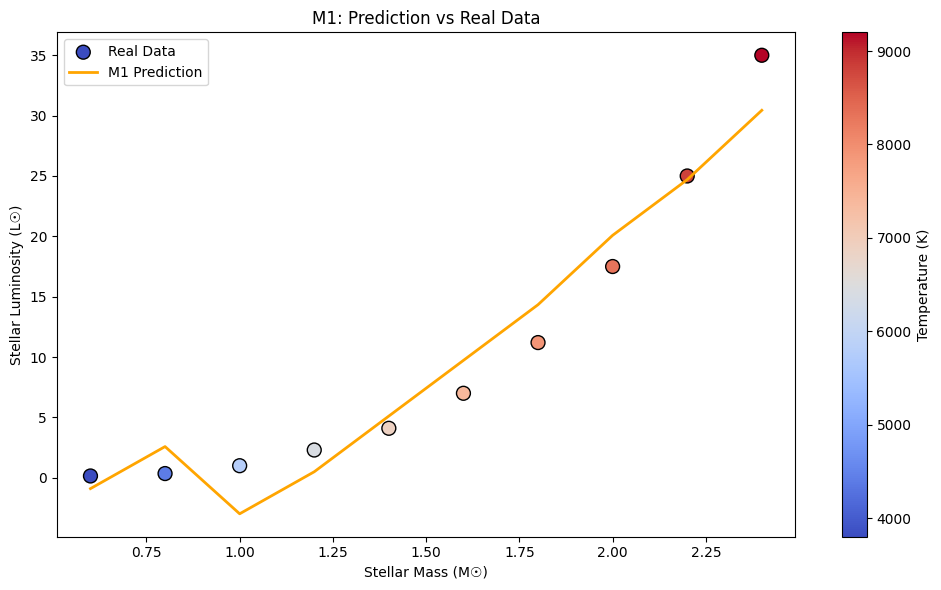

In [58]:
X = np.column_stack((stellar_mass, effective_stellar_temperature))
X_norm= z_score_normalize(X)

w_init = np.zeros(2)
b_init = 0.0

w_learned, b_learned, it_hist, cost_hist = gradient_descent(
    X_norm, stellar_luminosity, w_init, b_init, alpha, num_iterations
)

# Calculate metrics
y_predicted = predict(X_norm, w_learned, b_learned)
cost = compute_cost(X_norm, stellar_luminosity, w_learned, b_learned)

print(f"\nM1 Results:")
print(f"  w = {w_learned}")
print(f"  b = {b_learned:.4f}")
print(f"  Final Cost = {cost:.6f}")

fig, ax = plt.subplots(figsize=(10, 6))

# Prediction Graphic
scatter = ax.scatter(stellar_mass, stellar_luminosity, c=effective_stellar_temperature,
                      cmap='coolwarm', s=100, edgecolors='black', label='Real Data')
ax.plot(stellar_mass, y_predicted, 'b-', color = "orange",linewidth=2, label=f'M1 Prediction')
ax.set_xlabel('Stellar Mass (M☉)')
ax.set_ylabel('Stellar Luminosity (L☉)')
ax.set_title('M1: Prediction vs Real Data')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Temperature (K)')

plt.tight_layout()
plt.show()


## **M2:** X = [M, T, M²]


M2 Results:
  w = [-17.702    1.4858  27.0426]
  b = 10.3600
  Final Cost = 0.267224


/tmp/ipython-input-250543423.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(stellar_mass, y_predicted, 'b-', color = "navy",linewidth=2, label=f'M2 Prediction')


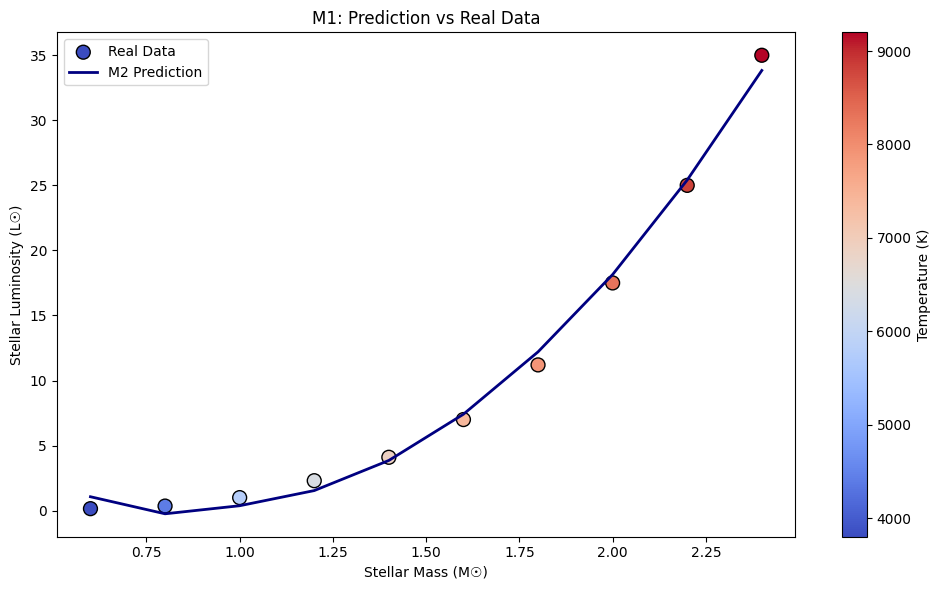

In [59]:
X = np.column_stack((stellar_mass, effective_stellar_temperature,stellar_mass**2))
X_norm= z_score_normalize(X)

w_init = np.zeros(3)
b_init = 0.0

w_learned, b_learned, it_hist, cost_hist = gradient_descent(
    X_norm, stellar_luminosity, w_init, b_init, alpha, num_iterations
)

# Calculate metrics
y_predicted = predict(X_norm, w_learned, b_learned)
cost = compute_cost(X_norm, stellar_luminosity, w_learned, b_learned)

print(f"\nM2 Results:")
print(f"  w = {w_learned}")
print(f"  b = {b_learned:.4f}")
print(f"  Final Cost = {cost:.6f}")

fig, ax = plt.subplots(figsize=(10, 6))

# Prediction Graphic
scatter = ax.scatter(stellar_mass, stellar_luminosity, c=effective_stellar_temperature,
                      cmap='coolwarm', s=100, edgecolors='black', label='Real Data')
ax.plot(stellar_mass, y_predicted, 'b-', color = "navy",linewidth=2, label=f'M2 Prediction')
ax.set_xlabel('Stellar Mass (M☉)')
ax.set_ylabel('Stellar Luminosity (L☉)')
ax.set_title('M1: Prediction vs Real Data')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Temperature (K)')

plt.tight_layout()
plt.show()


## **M3:** X = [M, T, M², M*T]


M2 Results:
  w = [-0.2246 -1.0631  5.3574  7.2501]
  b = 10.3600
  Final Cost = 0.010456


/tmp/ipython-input-2685439785.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(stellar_mass, y_predicted, 'b-', color = "deepskyblue",linewidth=2, label=f'M3 Prediction')


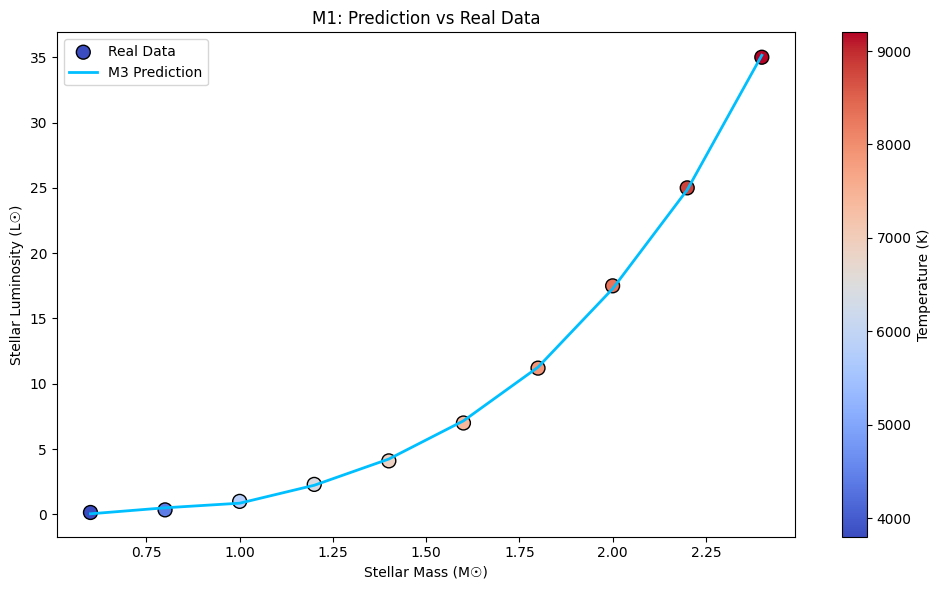

In [60]:
X = np.column_stack((stellar_mass, effective_stellar_temperature,stellar_mass**2,
                     stellar_mass*stellar_luminosity))
X_norm= z_score_normalize(X)

w_init = np.zeros(4)
b_init = 0.0

w_learned, b_learned, it_hist, cost_hist = gradient_descent(
    X_norm, stellar_luminosity, w_init, b_init, alpha, num_iterations
)

# Calculate metrics
y_predicted = predict(X_norm, w_learned, b_learned)
cost = compute_cost(X_norm, stellar_luminosity, w_learned, b_learned)

print(f"\nM2 Results:")
print(f"  w = {w_learned}")
print(f"  b = {b_learned:.4f}")
print(f"  Final Cost = {cost:.6f}")

fig, ax = plt.subplots(figsize=(10, 6))

# Prediction Graphic
scatter = ax.scatter(stellar_mass, stellar_luminosity, c=effective_stellar_temperature,
                      cmap='coolwarm', s=100, edgecolors='black', label='Real Data')
ax.plot(stellar_mass, y_predicted, 'b-', color = "deepskyblue",linewidth=2, label=f'M3 Prediction')
ax.set_xlabel('Stellar Mass (M☉)')
ax.set_ylabel('Stellar Luminosity (L☉)')
ax.set_title('M1: Prediction vs Real Data')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Temperature (K)')

plt.tight_layout()
plt.show()


## Comparing the 3 models


In [61]:
print("="*70)
print("Review")
print("="*70)

# Define all the models
models = {
    'M1: [M, T]': np.column_stack((stellar_mass, effective_stellar_temperature)),
    'M2: [M, T, M²]': np.column_stack((stellar_mass, effective_stellar_temperature, stellar_mass**2)),
    'M3: [M, T, M², M*T]': np.column_stack((stellar_mass, effective_stellar_temperature, stellar_mass**2, stellar_mass*effective_stellar_temperature)),
}

results = []

for model_name, X in models.items():
    X_norm = z_score_normalize(X)
    n_features = X.shape[1]
    w_init = np.zeros(n_features)
    b_init = 0.0

    w_learned, b_learned, it_hist, cost_hist = gradient_descent(
        X_norm, stellar_luminosity, w_init, b_init, alpha, num_iterations, verbose=False
    )

    y_pred = predict(X_norm, w_learned, b_learned)
    final_cost = cost_hist[-1]

    results.append({
        'Model': model_name,
        'Features': n_features,
        'Cost': final_cost,
    })


df_results = pd.DataFrame(results)
print("\n")
print(df_results.to_string(index=False))


Review


              Model  Features     Cost
         M1: [M, T]         2 3.552692
     M2: [M, T, M²]         3 0.267224
M3: [M, T, M², M*T]         4 0.298352


With this scenario, it seems the best model is M2 but it also depends on how many interactions and the alpha value.